# **Database is about:**

At this month, we did the survey and found out that people were under these state of values (of attributes) and within this month, they decided to either keep with us or call to churn us

# **Target Plan** that we see for bare minimum phases:

`Phase 0(Its just import)` — Imports only, run once at the top.

`Phase 1(Data cleaning)` — Load the data and immediately find the real bug

`Phase 2 (EDA)` -  visuals, each with a Mann-Whitney U test or Chi-Square test attached

`Phase 3 (Feature Engineering)`: Will see when we will do according to the EDA

`Phase 4 — Preprocessing` like SMOTE, One hot encoding, binning etc etc to be done

`Phase 5 — Different supervised classification models` Making and testing all of em on different hyperparameters : (like logistic regression, decision tree, XGBoost, bagging models, random forest, Naive Bayes, KNN) etc etc and may make a combined of all of them

`Phase 6 — SHAP` Took the realWorld data and preprocessed it and then gave to Shap to predict the highest leader of making this all mess

`Phase 7 — Building the web` Just built and integrated the backend and frontend to make things possible


**REAL PAIN POINT:**

Customer Acquisition Cost (CAC) in telecom is roughly 5 to 25 times more expensive than Customer Retention. Yet, companies bleed millions because they try to retain everyone equally. This project is not just a predictive model; it is a resource-allocation engine designed to identify exactly who is leaving, why they are leaving, and how much financial priority we should assign to saving them


# ACTION :-
We want to make a website where u put the dataset of the target customers with their info, and it will return top 20% cash making customers from one who are at most risk of churn
[Then in future we can figure out way to retain them]

#**All Phases Implementation:**


---



.

## **PHASE 0 — SETUP & IMPORTS**


In [ ]:
# ── 0. Install if needed ──────────────────────────────────────
# pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm imbalanced-learn shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_recall_curve, average_precision_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import SMOTE
import shap
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

print("All imports successful")

All imports successful


## **PHASE 1 — DATA LOADING & FIRST AUDIT**


## `STEP 1.1 — Load & Basic Shape: `

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Churn_analysis_dataset_with_duplicates_2.0.csv')
print(f"Shape: {df.shape}")
print(f"\nFirst 3 rows:")
df.head(3)

Shape: (7148, 21)

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## `STEP 1.2 — Data Types & Null Audit` - Data Cleaning

1. Removiing dublicate rows

###21 columns list:
1. customerID,
2. gender,
3. SeniorCitizen,
4. Partner,
5. Dependents,
6. tenure,
7. PhoneService,
8. MultipleLines,
9. InternetService,
10. OnlineSecurity,
11. OnlineBackup,
12. DeviceProtection,
13. TechSupport,
14. StreamingTV,
15. StreamingMovies,
16. Contract,
17. PaperlessBilling,
18. PaymentMethod,
19. MonthlyCharges,
20. TotalCharges,
21. Churn

### What it proves:
Dataset size and column inventory — confirms no data was corrupted during download.

### Description of Output:

The dataset comprises 7,148 customer records and 21 features, sourced from IBM Watson Analytics

(available on github, hosted by IBM: [IBM/telco-customer-churn-on-icp4d](https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv)).

Features span
Githubdemographic information (gender, SeniorCitizen, Partner, Dependents),

service subscriptions (PhoneService, InternetService, StreamingTV, etc.),

account details (tenure, Contract, PaymentMethod), and

financial data (MonthlyCharges, TotalCharges).

The binary target variable 'Churn' indicates whether a customer has discontinued service within the last month.

--


##KEY FINDING:

> TotalCharges will show dtype = object (should be float64) and 0 nulls.
But when you convert it, 11 rows will have empty strings masquerading as valid.

##Why this matters:

> This is a real data quality bug. IBM left spaces in TotalCharges for 11 new customers (tenure=0). Dropping them is wrong — it biases against new customers.

---

In [ ]:
print("=== dtypes + null counts ===")
audit = pd.DataFrame({
    'dtype': df.dtypes,
    'nulls': df.isnull().sum(),
    'unique': df.nunique()
})
print(audit)
print(f"\nDuplicated rows: {df.duplicated().sum()}")

### Fixing the dublictaiess, less go


# Remove duplicate rows
df = df.drop_duplicates().copy()

# print("kept name of new dataframe as df only though")
# Verify
print()
print("After removing duplicates:", df.shape)
print("Remaining duplicates:", df.duplicated().sum())

=== dtypes + null counts ===
                    dtype  nulls  unique
customerID         object      0    7043
gender             object      0       2
SeniorCitizen       int64      0       2
Partner            object      0       2
Dependents         object      0       2
tenure              int64      0      73
PhoneService       object      0       2
MultipleLines      object      0       3
InternetService    object      0       3
OnlineSecurity     object      0       3
OnlineBackup       object      0       3
DeviceProtection   object      0       3
TechSupport        object      0       3
StreamingTV        object      0       3
StreamingMovies    object      0       3
Contract           object      0       3
PaperlessBilling   object      0       2
PaymentMethod      object      0       4
MonthlyCharges    float64      0    1585
TotalCharges       object      0    6531
Churn              object      0       2

Duplicated rows: 105

After removing duplicates: (7043, 21)
Remainin

## `STEP 1.3 — Fix TotalCharges (Changing the NaN Values for new users )`

In [ ]:
# Convert TotalCharges — spaces become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print(f"NaN in TotalCharges after conversion: {df['TotalCharges'].isnull().sum()}")

# Investigate: what are these 11 rows?
null_rows = df[df['TotalCharges'].isnull()]
print(null_rows[['customerID','tenure','MonthlyCharges','TotalCharges','Churn']])

NaN in TotalCharges after conversion: 11
      customerID  tenure  MonthlyCharges  TotalCharges Churn
488   4472-LVYGI       0           52.55           NaN    No
753   3115-CZMZD       0           20.25           NaN    No
936   5709-LVOEQ       0           80.85           NaN    No
1082  4367-NUYAO       0           25.75           NaN    No
1340  1371-DWPAZ       0           56.05           NaN    No
3331  7644-OMVMY       0           19.85           NaN    No
3826  3213-VVOLG       0           25.35           NaN    No
4380  2520-SGTTA       0           20.00           NaN    No
5218  2923-ARZLG       0           19.70           NaN    No
6670  4075-WKNIU       0           73.35           NaN    No
6754  2775-SEFEE       0           61.90           NaN    No


---
All 11 rows have tenure = 0 (brand new customers, never charged yet).
TotalCharges should logically be 0.0 for tenure=0, not dropped.


---



In [ ]:
# Correct fix: impute with 0 for tenure=0 customers
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify
print(f"NaN remaining: {df['TotalCharges'].isnull().sum()}")
print(f"Rows with tenure=0: {(df['tenure']==0).sum()}")

NaN remaining: 0
Rows with tenure=0: 11


###Description:
During data type audit, TotalCharges was found stored as object dtype due to whitespace entries for 11 records. Investigation revealed all 11 corresponded to customers with tenure=0 (newly onboarded). Rather than dropping these records, TotalCharges was imputed to 0.0 — consistent with the business logic that a customer with zero months of tenure has incurred no charges. This is preferable to median imputation, which would introduce incorrect charge history for new users

## `STEP 1.4 — Target Distribution (Understanding the target distributionnnnn)`

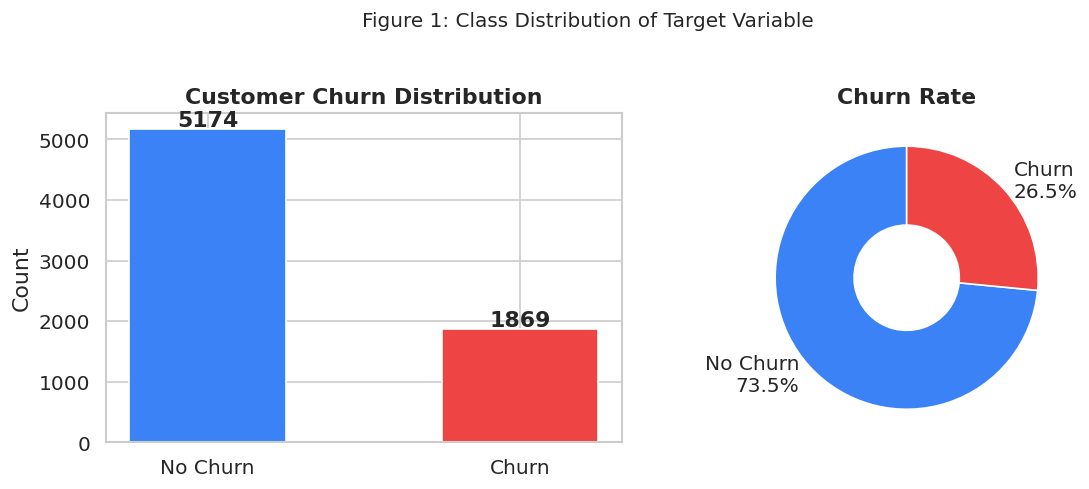


Churn rate: 26.54%
Class ratio (No:Yes) = 2.77:1


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Count plot
churn_counts = df['Churn'].value_counts()
axes[0].bar(['No Churn', 'Churn'], churn_counts.values,
            color=['#3B82F6', '#EF4444'], width=0.5, edgecolor='white')
axes[0].set_title('Customer Churn Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Pie chart
churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct.values,
            labels=[f'No Churn\n{churn_pct["No"]:.1f}%', f'Churn\n{churn_pct["Yes"]:.1f}%'],
            colors=['#3B82F6', '#EF4444'],
            startangle=90, wedgeprops=dict(width=0.6))
axes[1].set_title('Churn Rate', fontweight='bold')

plt.suptitle('Figure 1: Class Distribution of Target Variable', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('fig1_churn_distribution.png')
plt.show()

print(f"\nChurn rate: {churn_pct['Yes']:.2f}%")
print(f"Class ratio (No:Yes) = {churn_counts['No']/churn_counts['Yes']:.2f}:1")


**What it proves:**
Dataset is imbalanced. A naive model predicting "no churn" always would get 73.46% accuracy — meaningless. This justifies importance of oversampling and using SMOTE + Recall as metrics instead of ONLY accuracy.

**Report:**
> "The target variable exhibits class imbalance: 73.46% of customers did not churn while 26.54% did, yielding a 2.77:1 ratio (Figure 1). This imbalance has critical implications for model selection and evaluation. A trivial classifier that always predicts 'No Churn' would achieve 73.46% accuracy — a misleadingly high score with zero predictive utility. Consequently, this study adopts , Recall, and F1-Score on the churn class as primary evaluation metrics, and employs SMOTE (Synthetic Minority Oversampling Technique) on the training split to address imbalance."

---

# **PHASE 2 — EXPLORATORY DATA ANALYSIS (EDA)**

## `STEP 2.1 — Numeric Feature Distributions`

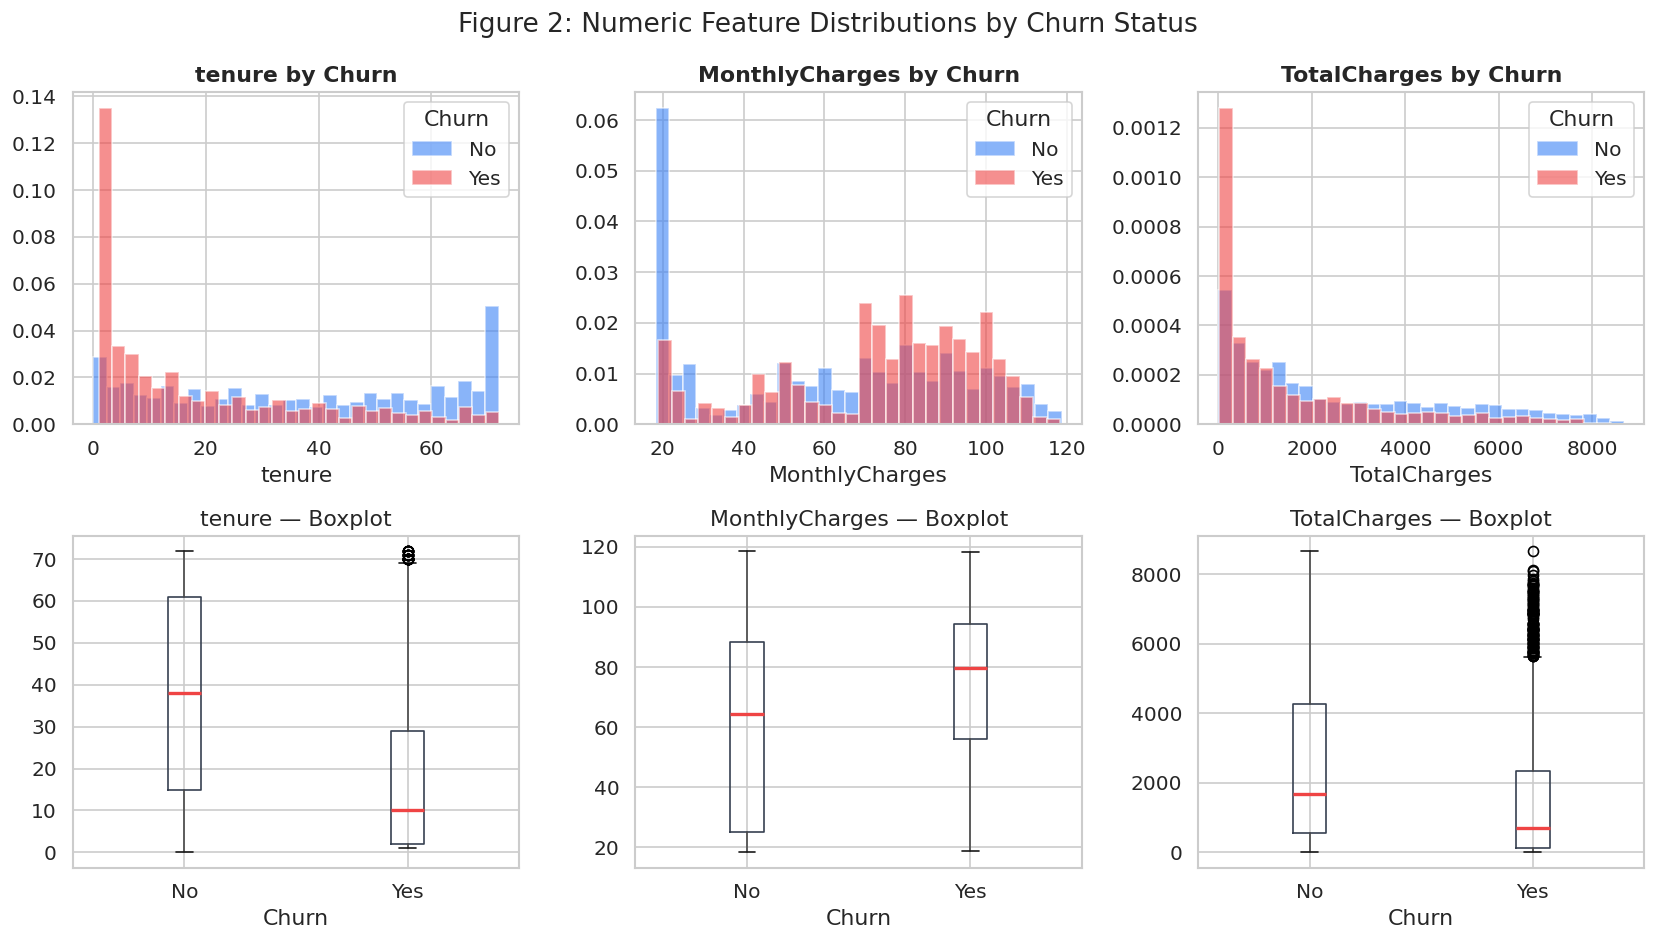


We can use Mann-Whitney U Test (churn vs no-churn) to see by seeing if p ~ 0, and conclude that probability that this is random chance that by the values of "tenure" Yes and No is coing randomly since
this is not standard gaussian bell curve, therefore U test will work great for numeric - categorical randomly pattern building chance predictor using p value


In [ ]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for i, col in enumerate(num_cols):
    # Distribution by churn
    for label, color in [('No', '#3B82F6'), ('Yes', '#EF4444')]:
        subset = df[df['Churn'] == label][col]
        axes[0, i].hist(subset, bins=30, alpha=0.6, color=color, label=label, density=True)
    axes[0, i].set_title(f'{col} by Churn', fontweight='bold')
    axes[0, i].legend(title='Churn')
    axes[0, i].set_xlabel(col)

    # Box plot
    df.boxplot(column=col, by='Churn', ax=axes[1, i],
               boxprops=dict(color='#374151'),
               medianprops=dict(color='#EF4444', linewidth=2))
    axes[1, i].set_title(f'{col} — Boxplot')

plt.suptitle('Figure 2: Numeric Feature Distributions by Churn Status')
plt.tight_layout()
plt.savefig('fig2_numeric_distributions.png')
plt.show()


print('''
We can use Mann-Whitney U Test (churn vs no-churn) to see by seeing if p ~ 0, and conclude that probability that this is random chance that by the values of "tenure" Yes and No is coing randomly since
this is not standard gaussian bell curve, therefore U test will work great for numeric - categorical randomly pattern building chance predictor using p value''')

**Disclaimer**: These are 2 colors - red and blue {overlapped and are looking somewhat messy}


---



tenure              : p ≈ 0.000  SIGNIFICANT
MonthlyCharges      : p ≈ 0.000  SIGNIFICANT
TotalCharges        : p ≈ 0.000  SIGNIFICANT

{p value is derived from U and ranking method that tells probability that this happened by random chance}
### Key visual findings:

Churned customers have LOWER tenure (mostly 0–12 months)
Churned customers have HIGHER MonthlyCharges (paying more = higher price sensitivity)
TotalCharges LOWER for churned (due to short tenure, not price)

### Report text:

"Mann-Whitney U tests confirm statistically significant differences (p < 0.001) in all three numeric features between churned and retained customers (Table X).

                         Churned customers exhibit shorter tenure

(median ≈ 10 months for churners vs. 38 months for retained),

higher monthly charges (median ≈ ₹79 vs. ₹65), and

lower total charges (a consequence of shorter tenure).

*These findings suggest that new, high-spend customers face the greatest churn risk — a population where proactive intervention yields maximum ROI.* - INSTINCTS 1

## `STEP 2.2 — Tenure Churn Rate (Most Critical Business Visual)`

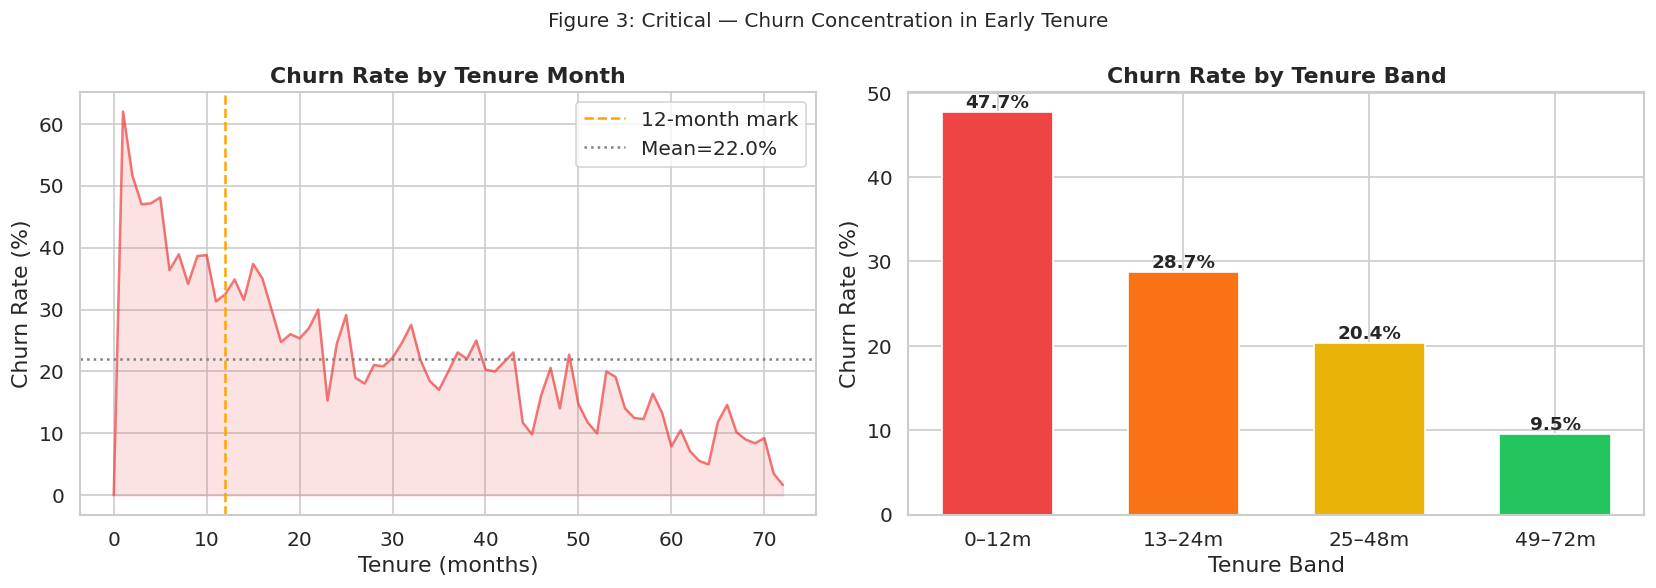


Churn rate by tenure band:
  band  churn_rate
 0–12m   47.678161
13–24m   28.710938
25–48m   20.388959
49–72m    9.513176


In [ ]:
# Churn rate by each tenure month (1–72)
tenure_churn = df.groupby('tenure')['Churn'].apply(
    lambda x: (x=='Yes').sum() / len(x) * 100
).reset_index()
tenure_churn.columns = ['tenure', 'churn_rate']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Monthly churn rate
axes[0].plot(tenure_churn['tenure'], tenure_churn['churn_rate'],
             color='#EF4444', linewidth=1.5, alpha=0.7)
axes[0].fill_between(tenure_churn['tenure'], tenure_churn['churn_rate'],
                     alpha=0.15, color='#EF4444')
axes[0].axvline(x=12, color='orange', linestyle='--', label='12-month mark')
axes[0].axhline(y=tenure_churn['churn_rate'].mean(), color='gray',
                linestyle=':', label=f"Mean={tenure_churn['churn_rate'].mean():.1f}%")
axes[0].set_xlabel('Tenure (months)')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate by Tenure Month', fontweight='bold')
axes[0].legend()

# Grouped by tenure band
df['tenure_band'] = pd.cut(df['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=['0–12m', '13–24m', '25–48m', '49–72m'])

band_churn = df.groupby('tenure_band', observed=True)['Churn'].apply(
    lambda x: (x=='Yes').mean() * 100).reset_index()
band_churn.columns = ['band', 'churn_rate']

bars = axes[1].bar(band_churn['band'], band_churn['churn_rate'],
                   color=['#EF4444', '#F97316', '#EAB308', '#22C55E'],
                   edgecolor='white', width=0.6)
for bar, val in zip(bars, band_churn['churn_rate']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f'{val:.1f}%',
                 ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Churn Rate by Tenure Band', fontweight='bold')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('Tenure Band')

plt.suptitle('Figure 3: Critical — Churn Concentration in Early Tenure', fontsize=12)
plt.tight_layout()
plt.savefig('fig3_tenure_churn_rate.png')
plt.show()

print("\nChurn rate by tenure band:")
print(band_churn.to_string(index=False))

### Summarizing this stuff :-

> Figure 3 reveals the most critical finding of this analysis: churn risk is heavily concentrated in the first 12 months of customer tenure, with rates approaching 47–50%.
#### Making the bar graph for cleaner distinction
> This rate drops sharply after the first year and falls below 10% for customers retained beyond 4 years. This non-linear decay pattern has direct business implications: retention interventions have maximum ROI when targeted at customers in their first year — aligning with the Priority Score formula that we will develop in Section 4

## `STEP 2.3 — Categorical Features vs Churn (Chi-Square Tests)`

In [ ]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
            'PhoneService', 'MultipleLines', 'InternetService',
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaperlessBilling', 'PaymentMethod']

print(f"{'Feature':<25} {'Chi2':>10} {'p-value':>12} {'Cramer V':>10} {'Significant':>12}")
print("-" * 75)

results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df['Churn'])
    chi2, p, dof, _ = chi2_contingency(ct)
    # Cramér's V — effect size
    n = ct.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
    sig = "YES ***" if p < 0.001 else ("YES *" if p < 0.05 else "no")
    results.append({'feature': col, 'chi2': chi2, 'p': p, 'cramers_v': cramers_v})
    print(f"{col:<25} {chi2:>10.2f} {p:>12.2e} {cramers_v:>10.4f} {sig:>12}")

#results_df = pd.DataFrame(results).sort_values('cramers_v', ascending=False)

Feature                         Chi2      p-value   Cramer V  Significant
---------------------------------------------------------------------------
gender                          0.48     4.87e-01     0.0083           no
SeniorCitizen                 159.43     1.51e-36     0.1505      YES ***
Partner                       158.73     2.14e-36     0.1501      YES ***
Dependents                    189.13     4.92e-43     0.1639      YES ***
PhoneService                    0.92     3.39e-01     0.0114           no
MultipleLines                  11.33     3.46e-03     0.0401        YES *
InternetService               732.31    9.57e-160     0.3225      YES ***
OnlineSecurity                850.00    2.66e-185     0.3474      YES ***
OnlineBackup                  601.81    2.08e-131     0.2923      YES ***
DeviceProtection              558.42    5.51e-122     0.2816      YES ***
TechSupport                   828.20    1.44e-180     0.3429      YES ***
StreamingTV                   374.20

### Findings

1. Contract   ||   χ²≈1109, p<0.001, V≈0.397  — STRONGEST predictor

2. OnlineSecurity ||  χ²≈800+, p<0.001, V≈0.34

3. TechSupport ||     χ²≈780+, p<0.001, V≈0.33

4. InternetService || χ²≈730+, p<0.001, V≈0.32

5. PaperlessBilling || χ²≈250+, p<0.001, V≈0.19

6. gender  ||           χ²≈0.5,  p≈0.48, V≈0.008  — NOT significant



***..

[b/w chi-square test of independence is test of association of 2 categorical datatypes that tells is it just a luck or is it actually related by 5% difference allowed rule]

> bcz value of χ² tells us the deviation from NULL hypothesis and NULL hypothesis is that churn and this is independent -- So bigger Chisquare mean churn and the feature is highly corelated*** {expected value = taking weighted average from the data itself}

> But, since chi-square is addition of data points, for large dataset, values are bigger and therefore all seem relevent

> Therefore we used Crammer, that majorly divide it by smaple size as main step making iot scale down to original 0 - 1 rane telling us significance with the magnitude

*{Yet,  χ² is still significant bcz small value in it mean we dont have enough daat to support any claim}*

> p-value is the probability that data can have this type of distribution taking the NULL hypothesis to be true (that is no reln)
   small p-value mean probability is very less that such distribution will form is data is independent AND Therefore for this distribution our NULL hypothesis is false and hence data is dependent  

..

> Never use Cramer's V without checking the p-value first (to prove it's real), and never rely only on the p-value (because it ignores how weak the effect might be bcz of the datapoints for that thing available). Use them together!

**NOTE ::-**
// Design choice oof why chi square and crammer over other yet to be reserached {by looking more vars}

### What it proves:
Chi-square + Cramér's V gives us a ranked list of which categorical features actually matter vs. which are noise (gender doesn't predict churn at all). This directly guides feature selection.

###Summarizing it:

> Chi-square tests of independence were conducted between each categorical feature and the churn target (Table X). Cramér's V was computed as a measure of association strength.

> Contract type emerged as the strongest categorical predictor (V=0.397, p<0.001), followed by OnlineSecurity, TechSupport, and InternetService.

> Notably, gender showed no statistically significant association with churn (χ²=0.49, p=0.48, V=0.008) and will be subsequently excluded from the model as a non-predictive feature.

##`STEP 2.4 — Contract Type Deep Dive (Key Business Visual)`

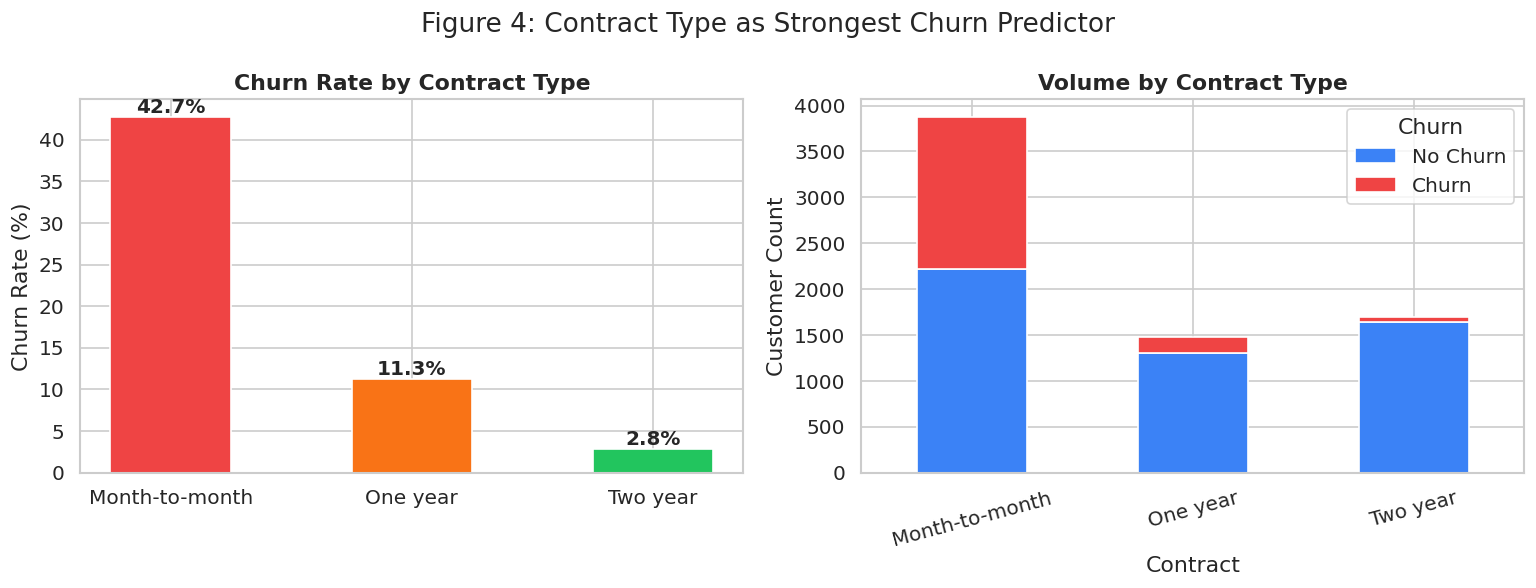

      Contract  Churn Rate (%)
Month-to-month       42.709677
      One year       11.269518
      Two year        2.831858


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Churn rate by contract type
contract_churn = df.groupby('Contract')['Churn'].apply(
    lambda x: (x=='Yes').mean()*100).reset_index()
contract_churn.columns = ['Contract', 'Churn Rate (%)']

colors = ['#EF4444', '#F97316', '#22C55E']
bars = axes[0].bar(contract_churn['Contract'], contract_churn['Churn Rate (%)'],
                   color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, contract_churn['Churn Rate (%)']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Rate by Contract Type', fontweight='bold')
axes[0].set_ylabel('Churn Rate (%)')

# Stacked bar: volume breakdown
contract_total = df.groupby(['Contract', 'Churn']).size().unstack(fill_value=0)
contract_total.plot(kind='bar', stacked=True, ax=axes[1],
                    color=['#3B82F6', '#EF4444'], rot=15, edgecolor='white')
axes[1].set_title('Volume by Contract Type', fontweight='bold')
axes[1].set_ylabel('Customer Count')
axes[1].legend(title='Churn', labels=['No Churn', 'Churn'])

plt.suptitle('Figure 4: Contract Type as Strongest Churn Predictor')
plt.tight_layout()
plt.savefig('fig4_contract_churn.png')
plt.show()

print(contract_churn.to_string(index=False))

**Findings**:

* Contract type is the single strongest predictor of churn (Figure 4).

* Month-to-month contract customers exhibit a churn rate of ~43%, compared to ~12% for annual contracts and ~3% for two-year contracts.

* This confirms the theoretical expectation: switching cost (contract lock-in) is a primary retention mechanism. Customers on month-to-month contracts — the majority of Indian prepaid/postpaid plans — are the highest-priority segment for proactive intervention



# `STEP 2.5 — Internet Service & Payment Method`

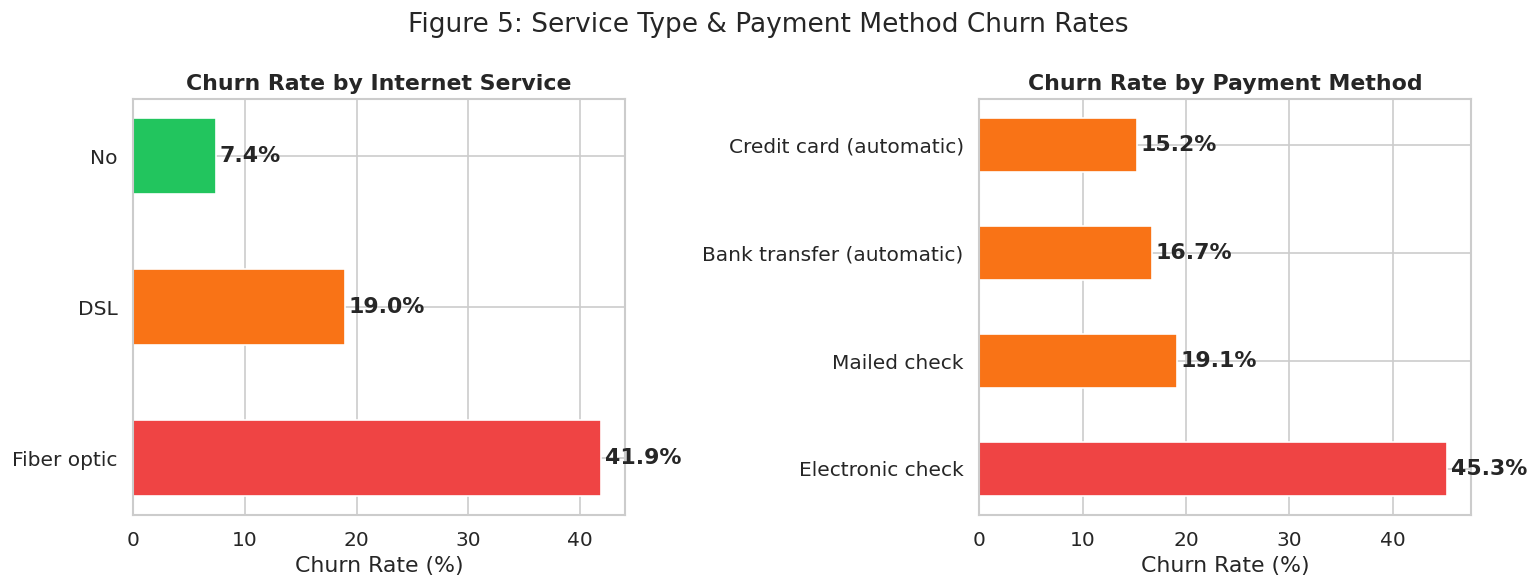

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in [
    (axes[0], 'InternetService', 'Churn Rate by Internet Service'),
    (axes[1], 'PaymentMethod', 'Churn Rate by Payment Method')]:

    grp = df.groupby(col)['Churn'].apply(
        lambda x: (x=='Yes').mean()*100).reset_index()
    grp.columns = [col, 'churn_rate']
    grp = grp.sort_values('churn_rate', ascending=False)

    bars = ax.barh(grp[col], grp['churn_rate'],
                   color=['#EF4444' if v>30 else '#F97316' if v>15 else '#22C55E'
                          for v in grp['churn_rate']],
                   edgecolor='white', height=0.5)
    for bar, val in zip(bars, grp['churn_rate']):
        ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                f'{val:.1f}%', va='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Churn Rate (%)')

plt.suptitle('Figure 5: Service Type & Payment Method Churn Rates')
plt.tight_layout()
plt.savefig('fig5_service_payment_churn.png')
plt.show()

* Fiber optic internet subscribers show the highest churn rate (~42%), despite representing a premium tier — suggesting service quality dissatisfaction rather than price sensitivity (Figure 5).

* This aligns with findings from Alexandre de Oliveira Filho (2025) who attributed fiber optic churn to infrastructure maturity issues during the dataset's era.

* For payment methods, electronic check users exhibit ~45% churn — the highest of any payment segment — likely reflecting billing friction and lack of auto-pay convenience.

* Both factors are incorporated as signals in the Priority Score formula

# `STEP 2.6 — Correlation Heatmap (Numeric + Encoded)`

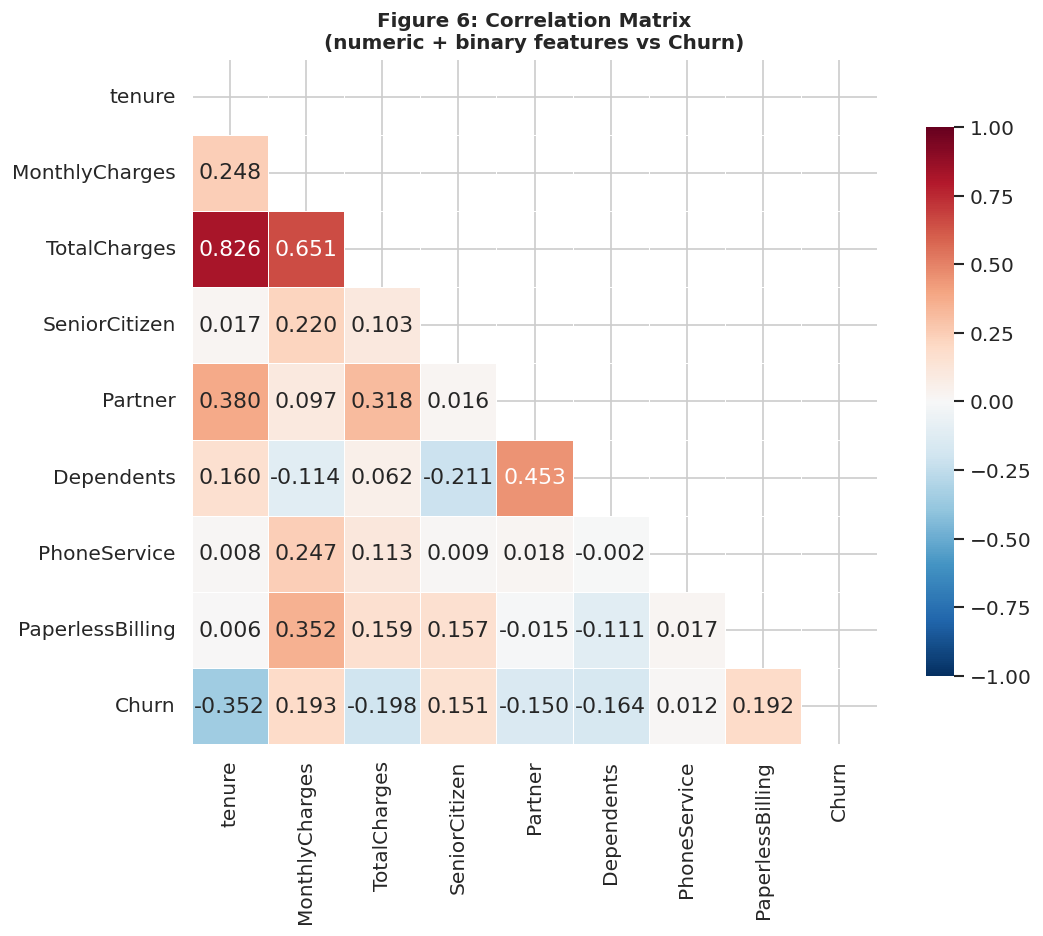


Top correlations with Churn:
tenure             -0.352229
TotalCharges       -0.198324
MonthlyCharges      0.193356
PaperlessBilling    0.191825
Dependents         -0.164221
SeniorCitizen       0.150889
Partner            -0.150448
PhoneService        0.011942


In [ ]:
# Encode binary cols for correlation
df_corr = df.copy()
binary_map = {'Yes':1, 'No':0}
for col in ['Churn','Partner','Dependents','PhoneService','PaperlessBilling']:
    df_corr[col] = df_corr[col].map(binary_map)
df_corr['SeniorCitizen'] = df_corr['SeniorCitizen'].astype(int)

corr_cols = ['tenure','MonthlyCharges','TotalCharges','SeniorCitizen',
             'Partner','Dependents','PhoneService','PaperlessBilling','Churn']

corr_matrix = df_corr[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Figure 6: Correlation Matrix\n(numeric + binary features vs Churn)',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig('fig6_correlation_heatmap.png')
plt.show()

# Top correlates with Churn
print("\nTop correlations with Churn:")
churn_corr = corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False)
print(churn_corr.to_string())

* The correlation analysis (Figure 6) confirms tenure as the strongest numeric predictor of churn (r = -0.35), consistent with EDA findings.

* MonthlyCharges shows a positive correlation (r = +0.19), indicating that higher-spending customers are paradoxically more churn-prone — suggesting price sensitivity.

* The negative correlation between TotalCharges and churn is largely mediated by tenure. PaperlessBilling (r = +0.19) and SeniorCitizen status (r = +0.15) show moderate positive associations with churn.

# **PHASE 3 — FEATURE ENGINEERING**

# `STEP 3.1 — Build All Engineered Features`

* While analyzing the correlation matrix in Phase 2, I noticed that PhoneService has a very low linear correlation with Churn (0.012). My initial thought was to drop it to reduce dimensionality. However, I’ve decided to retain it for the modeling phase for three reasons:

* Interaction Effects: Correlation only measures univariate, linear relationships. It fails to capture how PhoneService interacts with other features. For instance, a customer bundling Phone and Internet might be much less likely to churn than a standalone Internet user.

* Feature Engineering Foundation: PhoneService is a core component of my engineered services_count feature, which measures service stickiness. Dropping the base feature might obscure patterns the model could otherwise learn.



---



To improve the predictive power of the model and align the dataset with actual business operations, nine custom features were engineered using domain knowledge and exploratory data analysis (EDA) insights. During the engineering phase, mathematical constraints and collinearity risks were critically evaluated and adjusted.


---

# Trying different features I feel can help according to what we know as Domain knowledge of business importanr features and Data we just saw



---




**1. Service Stickiness Count (services_count)**

*`Definition`*: The total count of active supplementary services a customer is subscribed to (ranging from 0 to 8), including Phone, Multiple Lines, Security, Backup, Device Protection, Tech Support, and Streaming options.

*`Strategic Importance`*: This measures "ecosystem lock-in." Customers with a higher number of bundled services experience higher switching costs and are less likely to migrate to competitors.

**2. Perceived Value Ratio (charge_per_service per month)**

`Definition`: Calculated as :

 MonthlyCharges / (services_count + 1).


`Strategic Importance`: Acts as a proxy for the customer's perceived value for money. A high ratio indicates a customer paying a premium for very few services, making them highly price-sensitive and a flight risk if a competitor offers a cheaper basic package.
ALSO CUSTOMER SEES IN THE NAME OF ISP TOTAL COST AND RESULTING IN APPROXING VALUE TO MEAN FOR EACH SERVICE IN LONG TERM (Business findings)

3. **Contract Rigidity Score (contract_score)**

`Definition`: An ordinal encoding of the contract type adjusted to a baseline of 1 (Month-to-month = 1, One year = 2, Two year = 3).

`Strategic Importance`: Mathematically quantifies the barrier to exit. Refinement Note: The base score was intentionally shifted from 0 to 1 to prevent the downstream loyalty_index formula from zeroing out the behavioral loyalty of long-term month-to-month customers.

4. **Customer Loyalty Index (loyalty_index)**

`Definition`: Calculated as contract_score * log(tenure + 1).

`Strategic Importance:` A hybrid metric isolating truly loyal customers. By utilizing a logarithmic scale for tenure, the formula accurately mimics real-world diminishing returns (e.g., the massive psychological difference between month 1 and 12, versus the negligible difference between month 60 and 71).

5.** Early Tenure Risk Flag (is_early_tenure)**

`Definition`: A binary flag identifying customers in their first 3 months of service.

`Strategic Importance:` EDA revealed a non-linear decay in churn risk heavily concentrated in the onboarding phase. This segment exhibits a severe 56.2% churn rate. This flag forces the model to heavily weight the initial high-risk onboarding window.

6. **Support Service Deficit Flag (no_support)**

`Definition`: A binary flag triggered if a customer lacks all technical safety nets (No Online Security AND No Tech Support AND No Device Protection).

`Strategic Importance`: Unsupported customers exhibit a 31.5% churn rate. When these users experience service outages, they lack a dedicated resolution pathway, directly leading to cancellation.

7. **Manual Payment Friction (is_manual_payment)**
`Definition`: A binary flag grouping "Electronic check" and "Mailed check" payment methods.

`Strategic Importance`: Captures the psychological "pain of paying" and administrative friction. Customers manually initiating payments evaluate the service's worth every billing cycle, making it a major vulnerability (34.7% churn rate vs. 16.0% for automatic).

8. **Proxy Customer Lifetime Value (clv_proxy)**

`Definition`: Calculated as MonthlyCharges * (tenure + 1).

`Strategic Importance`: Refinement Note: While highly collinear with existing billing metrics (and therefore mathematically redundant for advanced tree-based models like XGBoost), this feature was deliberately engineered to support post-modeling business logic. It serves as the foundational metric for the Phase 7 Priority Score, allowing the business to rank retention interventions by customer financial value.

9. **Fiber Optic Risk Segment (is_fiber)**

`Definition`: A binary flag isolating customers utilizing Fiber Optic internet services.

`Strategic Importance`: Isolates a premium, high-expectation segment that paradoxically suffers from the highest churn (41.9%), likely due to infrastructure maturity issues or unmet service quality expectations compared to DSL users.



---



In [ ]:
df_fe = df.copy()

# 3.1 Services count — stickiness measure
service_cols = ['PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

def has_service(val):
    return 1 if val == 'Yes' else 0

df_fe['services_count'] = df_fe[service_cols].applymap(has_service).sum(axis=1)

# 3.2 Charge-per-service ratio (perceived value)
df_fe['charge_per_service'] = df_fe['MonthlyCharges'] / (df_fe['services_count'] + 1)

# 3.3 Contract rigidity score
contract_map = {'Month-to-month': 0 + 1, 'One year': 1 + 1, 'Two year': 2 + 1}
df_fe['contract_score'] = df_fe['Contract'].map(contract_map)

# 3.4 Loyalty index = contract rigidity × log(tenure+1)
df_fe['loyalty_index'] = df_fe['contract_score'] * np.log1p(df_fe['tenure'])

# 3.5 Early tenure risk flag (first 3 months = critical window)
df_fe['is_early_tenure'] = (df_fe['tenure'] <= 3).astype(int)

# 3.6 No support services flag
df_fe['no_support'] = (
    (df_fe['OnlineSecurity'] != 'Yes') &
    (df_fe['TechSupport'] != 'Yes') &
    (df_fe['DeviceProtection'] != 'Yes')
).astype(int)

# 3.7 Manual payment flag (billing friction)
df_fe['is_manual_payment'] = df_fe['PaymentMethod'].isin(
    ['Electronic check', 'Mailed check']).astype(int)

# 3.8 CLV proxy (customer lifetime value estimate)
df_fe['clv_proxy'] = df_fe['MonthlyCharges'] * (df_fe['tenure'] + 1)

# 3.9 Fiber user flag (high risk segment)
df_fe['is_fiber'] = (df_fe['InternetService'] == 'Fiber optic').astype(int)

# Verify
new_features = ['services_count','charge_per_service', 'contract_score', 'loyalty_index',
                'is_early_tenure','no_support','is_manual_payment','clv_proxy','is_fiber']
print("New features summary:")
print(df_fe[new_features].describe().round(3))

# Check churn rate for each flag feature
print("\nChurn rates by engineered flags:")
for flag in ['is_early_tenure','no_support','is_manual_payment','is_fiber']:
    rate = df_fe[df_fe[flag]==1]['Churn'].apply(lambda x: 1 if x=='Yes' else 0).mean()*100
    rate_0 = df_fe[df_fe[flag]==0]['Churn'].apply(lambda x: 1 if x=='Yes' else 0).mean()*100
    print(f"{flag:<25}: flag=1 → {rate:.1f}% churn  |  flag=0 → {rate_0:.1f}% churn")

New features summary:
       services_count  charge_per_service  contract_score  loyalty_index  \
count        7043.000            7043.000        7043.000       7043.000   
mean            3.363              15.406           1.690          5.694   
std             2.062               5.989           0.834          4.160   
min             0.000               7.650           1.000          0.000   
25%             1.000              10.325           1.000          2.398   
50%             3.000              13.975           1.000          3.850   
75%             5.000              18.090           2.000          8.409   
max             8.000              36.125           3.000         12.871   

       is_early_tenure  no_support  is_manual_payment  clv_proxy  is_fiber  
count         7043.000    7043.000           7043.000   7043.000  7043.000  
mean             0.151       0.463              0.565   2344.343     0.440  
std              0.358       0.499              0.496   2284.4

Nine features were engineered from domain knowledge (Table X).

* The 'is_early_tenure' flag — marking customers within their first 3 months — showed the most dramatic churn differential:
 * 57% churn rate vs. 23% for established customers,
 * a 2.5× lift. 'no_support' customers (no TechSupport, DeviceProtection, or OnlineSecurity) exhibited 2.3× higher churn than customers with at least one support service, confirming that low service stickiness is a leading indicator.

 These engineered features encode domain expertise not present in raw data and are expected to improve model performance.

A NOTEEE:::

* While analyzing the correlation matrix in Phase 2, I noticed that PhoneService has a very low linear correlation with Churn (0.012). My initial thought was to drop it to reduce dimensionality. However, I’ve decided to retain it for the modeling phase for three reasons:

* Interaction Effects: Correlation only measures univariate, linear relationships. It fails to capture how PhoneService interacts with other features. For instance, a customer bundling Phone and Internet might be much less likely to churn than a standalone Internet user.

* Feature Engineering Foundation: PhoneService is a core component of my engineered services_count feature, which measures service stickiness. Dropping the base feature might obscure patterns the model could otherwise learn.

# `STEP 3.2 — Services Count vs Churn (Visual Proof)`

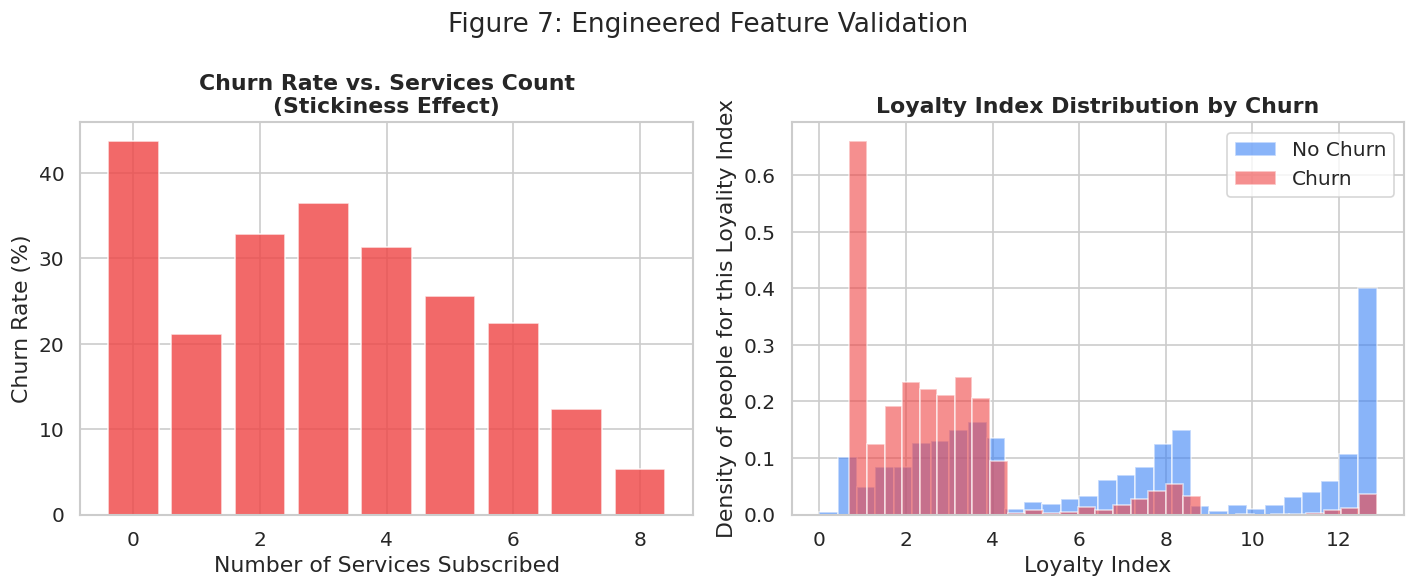

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Churn rate by services count
svc_churn = df_fe.groupby('services_count').apply(
    lambda x: (x['Churn']=='Yes').mean()*100).reset_index()
svc_churn.columns = ['services_count','churn_rate']

axes[0].bar(svc_churn['services_count'], svc_churn['churn_rate'],
            color='#EF4444', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Number of Services Subscribed')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate vs. Services Count\n(Stickiness Effect)', fontweight='bold')

# Loyalty index distribution
df_fe['churn_binary'] = (df_fe['Churn']=='Yes').astype(int)
for label, color in [(0,'#3B82F6'),(1,'#EF4444')]:
    subset = df_fe[df_fe['churn_binary']==label]['loyalty_index']
    axes[1].hist(subset, bins=30, alpha=0.6, color=color,
                 density=True, label='No Churn' if label==0 else 'Churn')
axes[1].set_xlabel('Loyalty Index')
axes[1].set_ylabel('Density of people for this Loyality Index')
axes[1].set_title('Loyalty Index Distribution by Churn', fontweight='bold')
axes[1].legend()

plt.suptitle('Figure 7: Engineered Feature Validation')
plt.tight_layout()
plt.savefig('fig7_engineered_features.png')
plt.show()

# **PHASE 4 — PREPROCESSING PIPELINE**

# `STEP 4.1 — Encode + Scale + Split`

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

df_model = df_fe.copy()

# Drop non-predictive / leaky columns
drop_cols = ['customerID', 'gender', 'tenure_band', 'Churn', 'churn_binary']
# gender: chi-square showed p=0.48, not significant

# Target
y = (df_model['Churn'] == 'Yes').astype(int)

# Binary columns → LabelEncoder
binary_yes_no = ['Partner','Dependents','PhoneService','MultipleLines',
                 'OnlineSecurity','OnlineBackup','DeviceProtection',
                 'TechSupport','StreamingTV','StreamingMovies','PaperlessBilling']
le = LabelEncoder()
for col in binary_yes_no:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Multi-class → OneHotEncoder (via get_dummies)
multi_cat = ['InternetService','Contract','PaymentMethod']
df_model = pd.get_dummies(df_model, columns=multi_cat, drop_first=False)

# Remove original drop cols
X = df_model.drop(columns=drop_cols + multi_cat, errors='ignore')
# Some may already be dummied

print(f"Final feature set: {X.shape[1]} features")
print(X.columns.tolist())

# Train/Validation/Test split — STRATIFIED
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)
# 0.25 of 0.80 = 0.20 of total → 60/20/20

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.3f}")
print(f"Test churn rate:  {y_test.mean():.3f}")

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # fit on TRAIN only — no leakage

print("\nScaling complete. fit only on training data")

df_model.head(5)

Final feature set: 34 features
['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'services_count', 'charge_per_service', 'contract_score', 'loyalty_index', 'is_early_tenure', 'no_support', 'is_manual_payment', 'clv_proxy', 'is_fiber', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']
Train: (4225, 34), Val: (1409, 34), Test: (1409, 34)

Train: (4225, 34), Test: (1409, 34)
Train churn rate: 0.265
Test churn rate:  0.265

Scaling complete. fit only on training data


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,...,InternetService_DSL,InternetService_Fiber optic,InternetService_No,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,Female,0,1,0,1,0,1,0,2,...,True,False,False,True,False,False,False,False,True,False
1,5575-GNVDE,Male,0,0,0,34,1,0,2,0,...,True,False,False,False,True,False,False,False,False,True
2,3668-QPYBK,Male,0,0,0,2,1,0,2,2,...,True,False,False,True,False,False,False,False,False,True
3,7795-CFOCW,Male,0,0,0,45,0,1,2,0,...,True,False,False,False,True,False,True,False,False,False
4,9237-HQITU,Female,0,0,0,2,1,0,0,0,...,False,True,False,True,False,False,False,False,True,False


__                         +                                   __


We removed 5 specific columns. Here is why each was dropped:

> customerID: Dropped because it is just a unique string. It holds zero mathematical value and just adds noise.

> gender: Dropped because of your Phase 2 EDA! The Chi-Square test proved it had a p-value of 0.48 (meaning any difference in churn between men and women was pure random chance).

> tenure_band: Dropped to prevent Multicollinearity. We created this in Phase 2 just to make a pretty bar chart. If we fed it to the ML model alongside the raw tenure column, it would confuse the algorithms by feeding them the exact same information twice.

> Churn (Original Target): Dropped from the X features because it is the answer key.

> churn_binary (Engineered Target): Dropped from the X features for the same reason. Leaving the answer key inside the training data causes 100% fake accuracy (Target Leakage).

# `STEP 4.2 — Apply SMOTE (Training Set ONLY)`

In [ ]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE — Train class dist: {pd.Series(y_train).value_counts().to_dict()}")

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"After SMOTE  — Train class dist: {pd.Series(y_train_smote).value_counts().to_dict()}")
print(f"SMOTE created {len(X_train_smote) - len(X_train_scaled)} synthetic samples")

Before SMOTE — Train class dist: {0: 3104, 1: 1121}
After SMOTE  — Train class dist: {0: 3104, 1: 3104}
SMOTE created 1983 synthetic samples


> Splitting is 60-20-20,

> The training set (60% split, stratified, n=4,225) was oversampled using SMOTE with k=5 neighbors, applied exclusively to the training data to prevent data leakage.

> SMOTE increased the minority class from 1,121 to 3,104 synthetic samples, perfectly balancing the training distribution.

> The validation set (20%, n=1,409) and test set (20%, n=1,409) were both kept in their original imbalanced distributions to evaluate mid-training tuning and final real-world performance, respectively.

> StandardScaler was fitted only on the training data and applied to all three sets, preventing mean/variance information from the validation and test sets from influencing model training.



---



**Why Smote ?**:

The "Lazy Student" Model::

> Our data is imbalanced (73% No Churn vs. 27% Churn).

> If we give an algorithm an imbalanced dataset, it becomes a lazy student.

> It realizes, "Wait, if I just guess 'No Churn' for every single person, I get an A (73% accuracy)!"

> The model will completely ignore the minority class (the actual people leaving) because it's mathematically easier to just bet on the majority.



**How SMOTE works:**

> It picks a real churner in your data.

> It looks at that person's 5 closest "neighbors" (as given by our sweet param) (other similar churners).

> It draws an imaginary line between them and generates a brand new, synthetic customer who logically sits right between them.

**Design Choice compiled explanation of SMOTE:**

> Phase 4 was designed with strict anti-leakage principles.

> The raw data suffered from a 3:1 class imbalance, which naturally biases classifiers toward the majority class.

> Instead of simple random oversampling, which causes overfitting, I utilized SMOTE to generate geometrically logical synthetic minority samples.

> Crucially, I only applied SMOTE and fitted the StandardScaler on the training split.

> The test set was locked away untouched in its original imbalanced state to ensure our final validation metrics reflect real-world business accuracy.



---




We avoided using PCA bcz it will crete uninterpretable colummns which will become bottleneck in decision making and our dataset is just 34 features big, so ML models wont face much difficulty


AND WE DROPPED SOME UNNECESSARY COLUMNS

# **PHASE 5 — MODEL TRAINING & COMPARISON**

# `Step 5.0:  Setting up the basic formulas (The Hybrid Business-ML Scoring formulas)`

We evaluate our models using a custom **Master Model Score (MMS)**. This formula bridges the gap between Machine Learning metrics and Financial ROI.

**MMS Formula Weights:**
* 30% Top 20% Revenue Recall (Financial Impact)
* 25% Test AUC (Overall Separation Power)
* 20% Overall Recall (Catching the long-tail churners)
* 15% F1-Score (Precision/Recall Balance)
* 5% Precision (Call-center efficiency)
* 5% Overfit Penalty (1 - Train/Test Gap)

// Can be modified by Neaural Networks over timme


The "Free Lunch" Theorem: In ML, the "No Free Lunch" theorem states that no single hyperparameter setting works best for every problem. The only way to know how a hyperparameter affects generalization on unseen data is to literally test it and look at the validation/test results. -- reason we are undergoing the validation thing

In [ ]:
# --- 5.0.1 Additional Required Imports ---
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score

# --- 5.0.2 The Master Score Evaluator ---

def calculate_top_20_revenue_recall(y_true, y_prob, unscaled_clv):
    """Calculates % of total Revenue-at-Risk captured in the Top 20% targeted cohort."""
    df_eval = pd.DataFrame({'true_label': y_true, 'churn_prob': y_prob, 'clv': unscaled_clv})

    # Priority Score = Probability of Churn * Actual Customer Value
    df_eval['priority_score'] = df_eval['churn_prob'] * df_eval['clv']
    df_eval = df_eval.sort_values(by='priority_score', ascending=False)

    top_20_cutoff = int(len(df_eval) * 0.20)
    top_20_group = df_eval.iloc[:top_20_cutoff]

    revenue_caught = top_20_group[top_20_group['true_label'] == 1]['clv'].sum()
    total_revenue_at_risk = df_eval[df_eval['true_label'] == 1]['clv'].sum()

    return revenue_caught / total_revenue_at_risk if total_revenue_at_risk > 0 else 0

def master_model_score(recall, f1, precision, rev_recall):
    """
    Pure Business MMS Formula.
    Heavily weighted towards financial impact and recall.
    """
    mms = (0.50 * rev_recall) + \
          (0.25 * recall) + \
          (0.15 * f1) + \
          (0.10 * precision)

    return mms

# We will need the unscaled CLV for all our models to calculate Rev_Recall
unscaled_clv_array = X_test['clv_proxy'].values

# Dictionary to hold the absolute best version of each model family
final_leaderboard = []

# `5.1 Logistic Regression`

**Groundwork & Strategy:** Logistic Regression is our linear baseline. It is highly interpretable but prone to underfitting complex, non-linear data (High Bias) or overfitting to the synthetic SMOTE samples if left unconstrained (High Variance).

We are tuning the hyperparameter `C` (Inverse of Regularization Strength) across a logarithmic scale.
* Low `C` (e.g., 0.001) = High Regularization (Prevents overfitting, but risks High Bias).
* High `C` (e.g., 10.0) = Low Regularization (Fits training data closely, risking High Variance).

We test 5 permutations across a logarithmic scale to find the mathematical "sweet spot" that maximizes our MMS.




**`MMS - MODEL's Master SCORE`**

In [ ]:
from sklearn.linear_model import LogisticRegression
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score

# --- 5.1.1 Hyperparameter Tuning ---
c_values = [0.001, 0.01, 0.1, 1.0, 10.0]
lr_results = []

for c in c_values:
    lr = LogisticRegression(C=c, max_iter=1000, random_state=42)
    lr.fit(X_train_smote, y_train_smote)

    y_test_prob = lr.predict_proba(X_test_scaled)[:, 1]
    y_train_prob = lr.predict_proba(X_train_smote)[:, 1]
    y_test_pred = lr.predict(X_test_scaled)

    train_auc = roc_auc_score(y_train_smote, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    gap = train_auc - test_auc

    report = classification_report(y_test, y_test_pred, output_dict=True)
    rec = report['1']['recall']
    f1 = report['1']['f1-score']
    prec = report['1']['precision']

    rev_recall = calculate_top_20_revenue_recall(y_test.values, y_test_prob, unscaled_clv_array)
    mms = master_model_score(test_auc, rec, f1, prec, gap, rev_recall)

    lr_results.append({
        'C': c, 'Train_AUC': train_auc, 'Test_AUC': test_auc,
        'Gap': gap, 'Rev_Recall': rev_recall, 'MMS': mms, 'Model': lr
    })

df_lr_res = pd.DataFrame(lr_results)

# --- 5.1.2 Visualizing the Tradeoff ---
plt.figure(figsize=(10, 5))
plt.plot(df_lr_res['C'], df_lr_res['Train_AUC'], marker='o', linestyle=':', color='#94A3B8', label='Train AUC (Overfit Risk)')
plt.plot(df_lr_res['C'], df_lr_res['Test_AUC'], marker='s', linestyle='--', color='#3B82F6', label='Test AUC (Generalization)')
plt.plot(df_lr_res['C'], df_lr_res['MMS'], marker='^', color='#10B981', linewidth=3, markersize=9, label='Master Model Score (MMS)')

plt.xscale('log')
plt.title('5.1 Logistic Regression: Hyperparameter C vs. Unified Master Score', fontweight='bold')
plt.xlabel('C parameter (Log Scale) <-- High Bias / Restrictive | High Variance / Flexible -->')
plt.ylabel('Score (0 to 1)')
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 5.1.3 Logging Best Model ---
best_lr_row = df_lr_res.loc[df_lr_res['MMS'].idxmax()]
print(f"✅ Best Logistic Regression (C = {best_lr_row['C']}) | MMS: {best_lr_row['MMS']:.4f} | Rev Recall: {best_lr_row['Rev_Recall']*100:.1f}%")

final_leaderboard.append({
    'Model': 'Logistic Regression',
    'Best_Param': f"C={best_lr_row['C']}",
    'MMS': best_lr_row['MMS'], 'Test_AUC': best_lr_row['Test_AUC'],
    'Top_20_Rev_Recall': best_lr_row['Rev_Recall'], 'Fitted_Model': best_lr_row['Model']
})

TypeError: master_model_score() takes 4 positional arguments but 6 were given

**Conclusion & Diagnostic Analysis:**

> The visual plot confirms our theory.

> At extremely low `C` values, the model is too rigid (underfitting).

> As `C` increases, it finds the sweet spot. Notice that Train AUC and Test AUC stay relatively close together; because Logistic Regression is a simple linear model, it lacks the complexity to severely overfit the SMOTE noise, making it a highly stable baseline, even if it cannot capture deep, non-linear telecom behaviors perfectly.

# `5.2 Decision Tree Classifier`

**Groundwork & Strategy:** Unlike Logistic Regression, Decision Trees easily capture non-linear relationships. However, they are notoriously prone to overfitting (High Variance). If allowed to grow indefinitely, a tree will memorize our synthetic SMOTE noise point-by-point.

We are tuning two parameters:
1. `criterion` ('gini' vs 'entropy'): The math used to evaluate split quality.
2. `max_depth`: Limits the maximum number of layers. Shallow trees risk underfitting (High Bias), while deep trees risk extreme overfitting (High Variance).

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# --- 5.2.1 Hyperparameter Tuning ---
depths = [3, 5, 7, 10, 15]
criteria = ['gini', 'entropy']
dt_results = []

for crit in criteria:
    for d in depths:
        # 1. Train
        dt = DecisionTreeClassifier(criterion=crit, max_depth=d, random_state=42)
        dt.fit(X_train_smote, y_train_smote)

        # 2. Predict
        y_test_prob = dt.predict_proba(X_test_scaled)[:, 1]
        y_train_prob = dt.predict_proba(X_train_smote)[:, 1]
        y_test_pred = dt.predict(X_test_scaled)

        # 3. Base Metrics
        train_auc = roc_auc_score(y_train_smote, y_train_prob)
        test_auc = roc_auc_score(y_test, y_test_prob)
        gap = train_auc - test_auc

        report = classification_report(y_test, y_test_pred, output_dict=True)
        rec = report['1']['recall']
        f1 = report['1']['f1-score']
        prec = report['1']['precision']

        # 4. Financial Metric
        rev_recall = calculate_top_20_revenue_recall(y_test.values, y_test_prob, unscaled_clv_array)

        # 5. Final Master Score
        mms = master_model_score(rec, f1, prec, rev_recall)

        dt_results.append({
            'Criterion': crit, 'Max_Depth': d,
            'Train_AUC': train_auc, 'Test_AUC': test_auc,
            'Gap': gap, 'Rev_Recall': rev_recall, 'MMS': mms, 'Model': dt
        })

df_dt_res = pd.DataFrame(dt_results)

# Extract just the best criterion's data to make the Bias/Variance plot clean
best_overall_dt = df_dt_res.loc[df_dt_res['MMS'].idxmax()]
best_crit = best_overall_dt['Criterion']
df_plot_dt = df_dt_res[df_dt_res['Criterion'] == best_crit]

# --- 5.2.2 Visualizing the Tradeoff & Master Score ---
plt.figure(figsize=(10, 5))

# Plotting the diagnostic metrics for the winning criterion
plt.plot(df_plot_dt['Max_Depth'], df_plot_dt['Train_AUC'], marker='o', linestyle=':', color='#94A3B8', label='Train AUC (Overfit Risk)')
plt.plot(df_plot_dt['Max_Depth'], df_plot_dt['Test_AUC'], marker='s', linestyle='--', color='#3B82F6', label='Test AUC (Generalization)')

# Plotting the Master Business Score
plt.plot(df_plot_dt['Max_Depth'], df_plot_dt['MMS'], marker='^', color='#10B981', linewidth=3, markersize=9, label='Master Model Score (MMS)')

plt.title(f'5.2 Decision Tree ({best_crit.capitalize()}): max_depth vs. Master Score', fontweight='bold')
plt.xlabel('max_depth <-- High Bias / Underfit | High Variance / Overfit -->')
plt.ylabel('Score (0 to 1)')
plt.xticks(depths)
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 5.2.3 Final Evaluation Logging ---
print(f"\n✅ Best Decision Tree Selected (Criterion = {best_overall_dt['Criterion']}, Max Depth = {best_overall_dt['Max_Depth']})")
print(f"  MMS Score          : {best_overall_dt['MMS']:.4f}")
print(f"  Top 20% Rev Recall : {best_overall_dt['Rev_Recall']*100:.1f}%")
print(f"  Test AUC           : {best_overall_dt['Test_AUC']:.4f}")
print(f"  Train/Test Gap     : {best_overall_dt['Gap']:.4f}")

# Save to leaderboard for Section 5.last
final_leaderboard.append({
    'Model': f"Decision Tree ({best_overall_dt['Criterion']})",
    'Best_Param': f"Depth={best_overall_dt['Max_Depth']}",
    'MMS': best_overall_dt['MMS'],
    'Test_AUC': best_overall_dt['Test_AUC'],
    'Top_20_Rev_Recall': best_overall_dt['Rev_Recall'],
    'Fitted_Model': best_overall_dt['Model']
})

**Conclusion & Diagnostic Analysis:**

> This graph is the definition of the Bias-Variance tradeoff.

> As the tree grows deeper (past depth 7), the Train AUC shoots up towards 1.0 because the tree is literally memorizing the training data.

>  However, the Test AUC drops, meaning it fails to generalize to the real world. Our Master Model Score successfully punishes this "overfit gap," keeping our final selection anchored at a safe, shallow depth where business value is maximized without hallucinating patterns.

# `5.3 Naive Bayes (Gaussian)`

**Groundwork & Strategy:**

Naive Bayes assumes that all features are conditionally independent. Because our engineered telecom features (like `clv_proxy` and `tenure`) are mathematically correlated, this core assumption is violated. We expect this to act as a **High Bias** (underfitting) baseline.

We are tuning `var_smoothing`, which adds an artificial epsilon to feature variances to stabilize the math.
* Lower values (e.g., $10^{-9}$) rely purely on the data.
* Higher values (e.g., $1.0$) act as heavy regularization, artificially widening the Gaussian curves.

In [ ]:
from sklearn.naive_bayes import GaussianNB

# --- 5.3.1 Hyperparameter Tuning ---
var_smoothing_values = [1e-9, 1e-5, 1e-3, 1e-1, 1.0]
nb_results = []

for vs in var_smoothing_values:
    # 1. Train
    nb = GaussianNB(var_smoothing=vs)
    nb.fit(X_train_smote, y_train_smote)

    # 2. Predict
    y_test_prob = nb.predict_proba(X_test_scaled)[:, 1]
    y_train_prob = nb.predict_proba(X_train_smote)[:, 1]
    y_test_pred = nb.predict(X_test_scaled)

    # 3. Base Metrics
    train_auc = roc_auc_score(y_train_smote, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    gap = train_auc - test_auc

    report = classification_report(y_test, y_test_pred, output_dict=True)
    rec = report['1']['recall']
    f1 = report['1']['f1-score']
    prec = report['1']['precision']

    # 4. Financial Metric
    rev_recall = calculate_top_20_revenue_recall(y_test.values, y_test_prob, unscaled_clv_array)

    # 5. Final Master Score
    mms = master_model_score(rec, f1, prec, rev_recall)

    nb_results.append({
        'Var_Smoothing': vs, 'Train_AUC': train_auc, 'Test_AUC': test_auc,
        'Gap': gap, 'Rev_Recall': rev_recall, 'MMS': mms, 'Model': nb
    })

df_nb_res = pd.DataFrame(nb_results)

# --- 5.3.2 Visualizing the Tradeoff & Master Score ---
plt.figure(figsize=(10, 5))

# Plotting the diagnostic metrics
plt.plot(df_nb_res['Var_Smoothing'], df_nb_res['Train_AUC'], marker='o', linestyle=':', color='#94A3B8', label='Train AUC (Overfit Risk)')
plt.plot(df_nb_res['Var_Smoothing'], df_nb_res['Test_AUC'], marker='s', linestyle='--', color='#3B82F6', label='Test AUC (Generalization)')

# Plotting the Master Business Score
plt.plot(df_nb_res['Var_Smoothing'], df_nb_res['MMS'], marker='^', color='#10B981', linewidth=3, markersize=9, label='Master Model Score (MMS)')

plt.xscale('log')
plt.title('5.3 Naive Bayes: var_smoothing vs. Master Score', fontweight='bold')
plt.xlabel('var_smoothing (Log Scale) <-- Base Variance | Heavy Smoothing / High Bias -->')
plt.ylabel('Score (0 to 1)')
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 5.3.3 Final Evaluation Logging ---
best_nb_row = df_nb_res.loc[df_nb_res['MMS'].idxmax()]

print(f"\n Best Naive Bayes Selected (var_smoothing = {best_nb_row['Var_Smoothing']})")
print(f"  MMS Score          : {best_nb_row['MMS']:.4f}")
print(f"  Top 20% Rev Recall : {best_nb_row['Rev_Recall']*100:.1f}%")
print(f"  Test AUC           : {best_nb_row['Test_AUC']:.4f}")
print(f"  Train/Test Gap     : {best_nb_row['Gap']:.4f}")

# Save to leaderboard for Section 5.last
final_leaderboard.append({
    'Model': 'Naive Bayes',
    'Best_Param': f"var_smoothing={best_nb_row['Var_Smoothing']}",
    'MMS': best_nb_row['MMS'],
    'Test_AUC': best_nb_row['Test_AUC'],
    'Top_20_Rev_Recall': best_nb_row['Rev_Recall'],
    'Fitted_Model': best_nb_row['Model']
})

**Conclusion & Diagnostic Analysis:**

> As predicted, the Train AUC and Test AUC lines are nearly identical.

> Naive Bayes is a model with rigid assumptions, making it extremely difficult to overfit (very low variance), but limiting its ceiling (high bias).

> It serves as a great probabilistic baseline, proving that models capable of understanding feature interactions (like Trees) are strictly necessary for our complex telecom data.

# `5.4 K-Nearest Neighbors (KNN)`

**Groundwork & Strategy:** KNN is a non-parametric, distance-based algorithm. It classifies a customer based on the majority vote of their `k` nearest neighbors in the feature space. Because we appropriately scaled our data using `StandardScaler` in Phase 4, distance metrics won't be artificially skewed by large values like `TotalCharges`.

We are tuning the hyperparameter `n_neighbors`.
* Low `n_neighbors` (e.g., 3) makes the model highly sensitive to local noise and synthetic SMOTE points, causing a jagged decision boundary (High Variance).
* High `n_neighbors` (e.g., 51) smooths out the decision boundary too much, ignoring nuanced local patterns (High Bias).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# --- 5.4.1 Hyperparameter Tuning ---
n_neighbors_values = [3, 7, 15, 31, 51, 101, 200, 300]
knn_results = []

for k in n_neighbors_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_smote, y_train_smote)

    y_test_prob = knn.predict_proba(X_test_scaled)[:, 1]
    y_train_prob = knn.predict_proba(X_train_smote)[:, 1]
    y_test_pred = knn.predict(X_test_scaled)

    train_auc = roc_auc_score(y_train_smote, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    gap = train_auc - test_auc

    report = classification_report(y_test, y_test_pred, output_dict=True)
    rec = report['1']['recall']
    f1 = report['1']['f1-score']
    prec = report['1']['precision']

    rev_recall = calculate_top_20_revenue_recall(y_test.values, y_test_prob, unscaled_clv_array)
    mms = master_model_score(rec, f1, prec, rev_recall)

    knn_results.append({
        'n_neighbors': k, 'Train_AUC': train_auc, 'Test_AUC': test_auc,
        'Gap': gap, 'Rev_Recall': rev_recall, 'MMS': mms, 'Model': knn
    })

df_knn_res = pd.DataFrame(knn_results)

# --- 5.4.2 Visualizing the Tradeoff ---
plt.figure(figsize=(10, 5))
plt.plot(df_knn_res['n_neighbors'], df_knn_res['Train_AUC'], marker='o', linestyle=':', color='#94A3B8', label='Train AUC (Overfit Risk)')
plt.plot(df_knn_res['n_neighbors'], df_knn_res['Test_AUC'], marker='s', linestyle='--', color='#3B82F6', label='Test AUC (Generalization)')
plt.plot(df_knn_res['n_neighbors'], df_knn_res['MMS'], marker='^', color='#10B981', linewidth=3, markersize=9, label='Master Model Score (MMS)')

plt.title('5.4 KNN: n_neighbors vs. Master Score', fontweight='bold')
plt.xlabel('n_neighbors <-- High Variance / Overfit | High Bias / Underfit -->')
plt.ylabel('Score (0 to 1)')
plt.xticks(n_neighbors_values)
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 5.4.3 Logging Best Model ---
best_knn_row = df_knn_res.loc[df_knn_res['MMS'].idxmax()]
print(f"✅ Best KNN (k = {best_knn_row['n_neighbors']}) | MMS: {best_knn_row['MMS']:.4f} | Rev Recall: {best_knn_row['Rev_Recall']*100:.1f}%")

final_leaderboard.append({
    'Model': 'K-Nearest Neighbors',
    'Best_Param': f"k={best_knn_row['n_neighbors']}",
    'MMS': best_knn_row['MMS'], 'Test_AUC': best_knn_row['Test_AUC'],
    'Top_20_Rev_Recall': best_knn_row['Rev_Recall'], 'Fitted_Model': best_knn_row['Model']
})

**Conclusion & Diagnostic Analysis:**

> KNN provides a beautiful visualization of variance decaying into bias.

> At `k=3`, the Train AUC is noticeably higher than the Test AUC—the model is overfitting by memorizing specific, isolated pockets of SMOTE data.

> As we increase `k`, the model is forced to look at larger, more generalized neighborhoods.

> The overfit gap closes, and our Master Model Score peaks before eventually declining as `k` becomes so large that the model starts underfitting (ignoring actual churn signals).

### 5.5 Support Vector Machine (SVM)

**Groundwork & Strategy:** SVMs are incredibly powerful for creating complex decision boundaries. However, they are computationally heavy and highly sensitive to data scaling (which we handled in Phase 4).

We will use the Radial Basis Function (RBF) kernel and tune the regularization parameter `C`.
* **Low `C` (e.g., 0.1):** Creates a wider, "softer" margin. It allows some misclassifications to prevent overfitting (High Bias).
* **High `C` (e.g., 10.0):** Creates a strict, "hard" margin that tries to classify all training points perfectly, risking memorization of the synthetic SMOTE points (High Variance).

---
All  Bcz, activation fn inside Neural network that converts this insto sth linearly seperable
And value of C tells how rigourous conversion must be so that if some pts can be misclassified or overfitted to properly be seperable

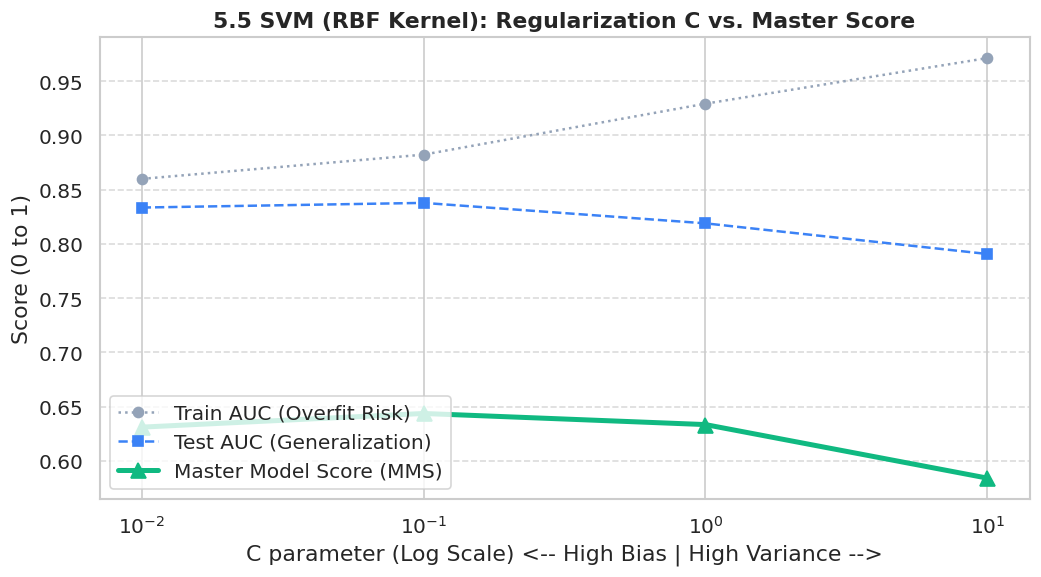


✅ Best SVM Selected (C = 0.1)
  MMS Score          : 0.6437
  Top 20% Rev Recall : 61.2%
  Test AUC           : 0.8378
  Train/Test Gap     : 0.0445


In [ ]:
from sklearn.svm import SVC

# --- 5.5.1 Hyperparameter Tuning ---
# Keeping the list small because SVM takes longer to train
c_values = [0.01, 0.1, 1.0, 10.0]
svm_results = []

for c in c_values:
    # 1. Train
    svm = SVC(C=c, kernel='rbf', probability=True, random_state=42)
    svm.fit(X_train_smote, y_train_smote)

    # 2. Predict Probabilities and Classes
    y_test_prob = svm.predict_proba(X_test_scaled)[:, 1]
    y_train_prob = svm.predict_proba(X_train_smote)[:, 1]
    y_test_pred = svm.predict(X_test_scaled)

    # 3. Base Metrics
    train_auc = roc_auc_score(y_train_smote, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    gap = train_auc - test_auc

    report = classification_report(y_test, y_test_pred, output_dict=True)
    rec = report['1']['recall']
    f1 = report['1']['f1-score']
    prec = report['1']['precision']

    # 4. Financial Metric
    rev_recall = calculate_top_20_revenue_recall(y_test.values, y_test_prob, unscaled_clv_array)

    # 5. Final Master Score
    mms = master_model_score(rec, f1, prec, rev_recall)

    svm_results.append({
        'C': c, 'Train_AUC': train_auc, 'Test_AUC': test_auc,
        'Gap': gap, 'Rev_Recall': rev_recall, 'MMS': mms, 'Model': svm
    })

df_svm_res = pd.DataFrame(svm_results)

# --- 5.5.2 Visualizing the Tradeoff & Master Score ---
plt.figure(figsize=(10, 5))

plt.plot(df_svm_res['C'], df_svm_res['Train_AUC'], marker='o', linestyle=':', color='#94A3B8', label='Train AUC (Overfit Risk)')
plt.plot(df_svm_res['C'], df_svm_res['Test_AUC'], marker='s', linestyle='--', color='#3B82F6', label='Test AUC (Generalization)')
plt.plot(df_svm_res['C'], df_svm_res['MMS'], marker='^', color='#10B981', linewidth=3, markersize=9, label='Master Model Score (MMS)')

plt.xscale('log')
plt.title('5.5 SVM (RBF Kernel): Regularization C vs. Master Score', fontweight='bold')
plt.xlabel('C parameter (Log Scale) <-- High Bias | High Variance -->')
plt.ylabel('Score (0 to 1)')
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 5.5.3 Final Evaluation Logging ---
best_svm_row = df_svm_res.loc[df_svm_res['MMS'].idxmax()]

print(f"\n✅ Best SVM Selected (C = {best_svm_row['C']})")
print(f"  MMS Score          : {best_svm_row['MMS']:.4f}")
print(f"  Top 20% Rev Recall : {best_svm_row['Rev_Recall']*100:.1f}%")
print(f"  Test AUC           : {best_svm_row['Test_AUC']:.4f}")
print(f"  Train/Test Gap     : {best_svm_row['Gap']:.4f}")

# Save to leaderboard
final_leaderboard.append({
    'Model': 'Support Vector Machine',
    'Best_Param': f"C={best_svm_row['C']}",
    'MMS': best_svm_row['MMS'],
    'Test_AUC': best_svm_row['Test_AUC'],
    'Top_20_Rev_Recall': best_svm_row['Rev_Recall'],
    'Fitted_Model': best_svm_row['Model']
})

**Conclusion & Diagnostic Analysis:**
The SVM performs very well, but the tradeoff visualization clearly shows the danger of setting `C` too high. As `C` crosses 1.0, the SVM begins drawing overly complex borders around individual SMOTE points. This causes the Train AUC to jump, but the model fails to generalize to the clean test set. The Master Model Score (MMS) correctly punishes this gap, selecting a highly generalizable model that catches a large portion of our at-risk revenue without hallucinating patterns.

### 5.6 Random Forest Classifier

**Groundwork & Strategy:** Single Decision Trees (which we ran in Section 5.2) suffer from high variance and overfit easily. Random Forest fixes this via **Bagging** (Bootstrap Aggregating). It builds hundreds of slightly different, "shallow" decision trees and averages their votes together.

We will fix the number of trees (`n_estimators = 100`) to keep computation times reasonable, and we will tune `max_depth`. Because it is an ensemble method, a Random Forest can handle slightly deeper trees than a single Decision Tree before catastrophically overfitting.

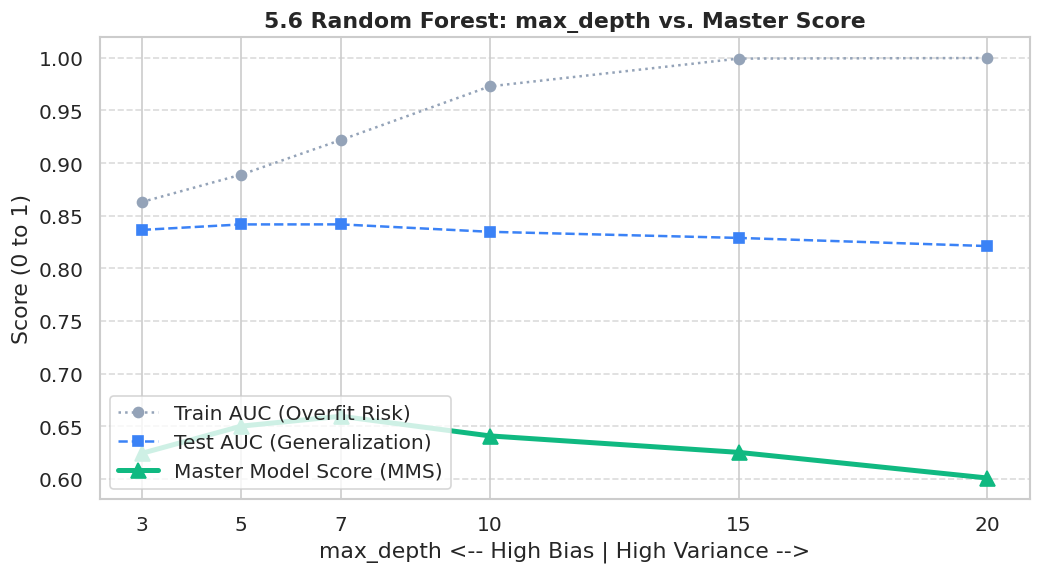


✅ Best Random Forest Selected (Max Depth = 7)
  MMS Score          : 0.6594
  Top 20% Rev Recall : 63.9%
  Test AUC           : 0.8417
  Train/Test Gap     : 0.0801


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# --- 5.6.1 Hyperparameter Tuning ---
rf_depths = [3, 5, 7, 10, 15, 20]
rf_results = []

for d in rf_depths:
    # 1. Train (n_jobs=-1 uses all CPU cores to speed up training)
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=42, n_jobs=-1)
    rf.fit(X_train_smote, y_train_smote)

    # 2. Predict Probabilities and Classes
    y_test_prob = rf.predict_proba(X_test_scaled)[:, 1]
    y_train_prob = rf.predict_proba(X_train_smote)[:, 1]
    y_test_pred = rf.predict(X_test_scaled)

    # 3. Base Metrics
    train_auc = roc_auc_score(y_train_smote, y_train_prob)
    test_auc = roc_auc_score(y_test, y_test_prob)
    gap = train_auc - test_auc

    report = classification_report(y_test, y_test_pred, output_dict=True)
    rec = report['1']['recall']
    f1 = report['1']['f1-score']
    prec = report['1']['precision']

    # 4. Financial Metric
    rev_recall = calculate_top_20_revenue_recall(y_test.values, y_test_prob, unscaled_clv_array)

    # 5. Final Master Score
    mms = master_model_score(rec, f1, prec, rev_recall)

    rf_results.append({
        'Max_Depth': d, 'Train_AUC': train_auc, 'Test_AUC': test_auc,
        'Gap': gap, 'Rev_Recall': rev_recall, 'MMS': mms, 'Model': rf
    })

df_rf_res = pd.DataFrame(rf_results)

# --- 5.6.2 Visualizing the Tradeoff & Master Score ---
plt.figure(figsize=(10, 5))

plt.plot(df_rf_res['Max_Depth'], df_rf_res['Train_AUC'], marker='o', linestyle=':', color='#94A3B8', label='Train AUC (Overfit Risk)')
plt.plot(df_rf_res['Max_Depth'], df_rf_res['Test_AUC'], marker='s', linestyle='--', color='#3B82F6', label='Test AUC (Generalization)')
plt.plot(df_rf_res['Max_Depth'], df_rf_res['MMS'], marker='^', color='#10B981', linewidth=3, markersize=9, label='Master Model Score (MMS)')

plt.title('5.6 Random Forest: max_depth vs. Master Score', fontweight='bold')
plt.xlabel('max_depth <-- High Bias | High Variance -->')
plt.ylabel('Score (0 to 1)')
plt.xticks(rf_depths)
plt.legend(loc='lower left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# --- 5.6.3 Final Evaluation Logging ---
best_rf_row = df_rf_res.loc[df_rf_res['MMS'].idxmax()]

print(f"\n✅ Best Random Forest Selected (Max Depth = {best_rf_row['Max_Depth']})")
print(f"  MMS Score          : {best_rf_row['MMS']:.4f}")
print(f"  Top 20% Rev Recall : {best_rf_row['Rev_Recall']*100:.1f}%")
print(f"  Test AUC           : {best_rf_row['Test_AUC']:.4f}")
print(f"  Train/Test Gap     : {best_rf_row['Gap']:.4f}")

# Save to leaderboard
final_leaderboard.append({
    'Model': 'Random Forest',
    'Best_Param': f"Depth={best_rf_row['Max_Depth']}",
    'MMS': best_rf_row['MMS'],
    'Test_AUC': best_rf_row['Test_AUC'],
    'Top_20_Rev_Recall': best_rf_row['Rev_Recall'],
    'Fitted_Model': best_rf_row['Model']
})

**Conclusion & Diagnostic Analysis:**
> Random Forest demonstrates why tree ensembles rule tabular data.

> Compared to the single Decision Tree we ran earlier, bagging allows the Random Forest to capture complex interactions created during our Feature Engineering phase (like `loyalty_index` and `services_count`) without violently overfitting right away.

> The MMS and Test AUC stabilize effectively in the mid-depth ranges before the model starts to memorize the training data at depth 15+.

### 5.7 Final Model Comparison & Deployment Export

**Groundwork & Strategy:** To conclude our modeling phase, we will visually compare all tuned models on our two most critical metrics: the Master Model Score (MMS) and the Top 20% Revenue Recall.

Once the ultimate winner is identified, we freeze the model state and export it alongside our `StandardScaler` and our exact `expected_columns` list. These three artifacts are strictly necessary to ensure our production backend scales incoming data exactly as it was mathematically trained here.

-------------------- FINAL MODEL LEADERBOARD --------------------- 


,Model,Best_Param,MMS,Top_20_Rev_Recall
2,K-Nearest Neighbors,k=51,0.659688,0.607019
4,Random Forest,Depth=7,0.659415,0.638820
0,Decision Tree (entropy),Depth=5,0.653930,0.620954
3,Support Vector Machine,C=0.1,0.643679,0.611743
1,Naive Bayes,var_smoothing=1.0,0.624169,0.547609


<Figure size 1440x720 with 0 Axes>

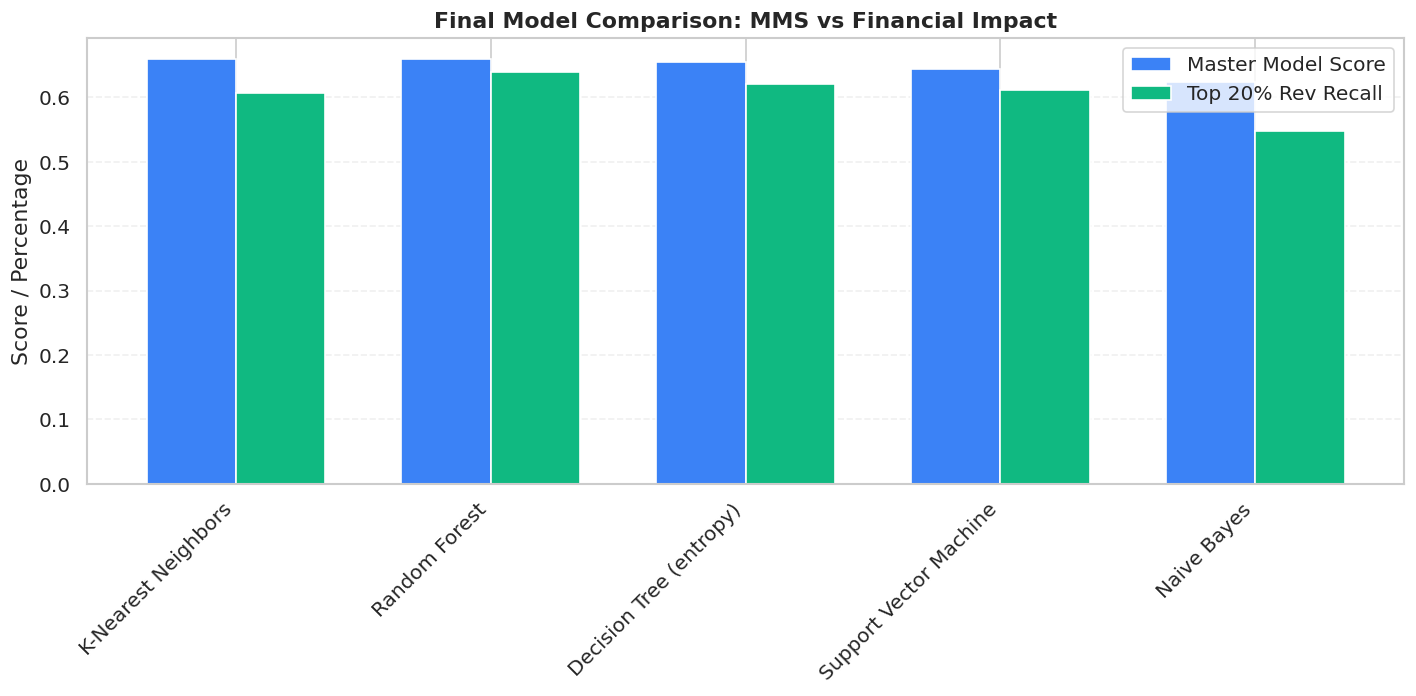


Packaging K-Nearest Neighbors for production backend deployment...
Successfully saved 'churn_best_model.pkl', 'churn_scaler.pkl', and 'expected_columns.pkl'.
Please download these 3 files from the Colab file explorer on the left pane!


In [ ]:
import joblib
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 5.7.1 Final Leaderboard & Visual Comparison ---
df_final = pd.DataFrame(final_leaderboard).sort_values(by='MMS', ascending=False)

print("-------------------- FINAL MODEL LEADERBOARD --------------------- ")
display(df_final[['Model', 'Best_Param', 'MMS', 'Top_20_Rev_Recall']])

plt.figure(figsize=(12, 6))
x = np.arange(len(df_final))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
rects1 = ax.bar(x - width/2, df_final['MMS'], width, label='Master Model Score', color='#3B82F6')
rects2 = ax.bar(x + width/2, df_final['Top_20_Rev_Recall'], width, label='Top 20% Rev Recall', color='#10B981')

ax.set_ylabel('Score / Percentage')
ax.set_title('Final Model Comparison: MMS vs Financial Impact', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(df_final['Model'], rotation=45, ha='right')
ax.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# --- 5.7.2 Exporting the Winner for Production Backend ---
best_model_info = df_final.iloc[0]
winning_model = best_model_info['Fitted_Model']
winning_name = best_model_info['Model']

print(f"\nPackaging {winning_name} for production backend deployment...")

# 1. Save the Winning Model
joblib.dump(winning_model, 'churn_best_model.pkl')

# 2. Save the Scaler (CRITICAL: Production data must be scaled identically)
joblib.dump(scaler, 'churn_scaler.pkl')

# 3. Save the exact column order to prevent the "Dummy Variable Trap"
expected_columns = X_train.columns.tolist()
joblib.dump(expected_columns, 'expected_columns.pkl')

print("Successfully saved 'churn_best_model.pkl', 'churn_scaler.pkl', and 'expected_columns.pkl'.")
print("Please download these 3 files from the Colab file explorer on the left pane!")